In [12]:

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load dataset
fire_df = pd.read_excel("fire_parameters.xlsx")

import numpy as np

# Extract month from fire date
fire_df["month"] = fire_df["date"].dt.month

# Cyclic encoding of month (to handle circularity of seasons)
fire_df["month_sin"] = np.sin(2 * np.pi * fire_df["month"] / 12)
fire_df["month_cos"] = np.cos(2 * np.pi * fire_df["month"] / 12)


# Features you want to cluster on
features = [
    'Elevation',
    'Slope',
    'Aspect',
    'LandCover',
    'TreeCover',
    'Population',
    'DistanceRoad',
    'DistanceSettlement',
    'Temperature',
    'Humidity',
    'WindSpeed',
    'Precip3Days',
    'NDVI',
    'MSI',
    'month_sin',
    'month_cos'
]

# --- 1. Select feature data ---
X_raw = fire_df[features]

# --- 2. Impute missing values with median ---
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_raw)

# --- 3. Scale features ---
scaler = StandardScaler()
X = scaler.fit_transform(X_imputed)

print("✅ Data cleaned and ready for clustering")
print("Shape:", X.shape)


✅ Data cleaned and ready for clustering
Shape: (8630, 16)


In [1]:
"""
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# --- 1. Load dataset ---
fire_df = pd.read_excel("fire_parameters.xlsx")

# --- 2. Extract month for seasonality ---
fire_df["month"] = pd.to_datetime(fire_df["date"], errors='coerce').dt.month

# --- 3. Encode seasonality cyclically ---
fire_df["month_sin"] = np.sin(2 * np.pi * fire_df["month"] / 12)
fire_df["month_cos"] = np.cos(2 * np.pi * fire_df["month"] / 12)

# --- 4. Define feature columns ---
features = [
    'Elevation', 'Slope', 'Aspect', 'LandCover', 'TreeCover',
    'Population', 'DistanceRoad', 'DistanceSettlement',
    'Temperature', 'Humidity', 'WindSpeed', 'Precip3Days',
    'NDVI', 'MSI', 'month_sin', 'month_cos'
]

# --- 5. Drop rows where any of the required features are missing ---
initial_count = len(fire_df)
fire_df = fire_df.dropna(subset=features)
dropped = initial_count - len(fire_df)
print(f"🧹 Dropped {dropped} incomplete rows — remaining {len(fire_df)}")

# --- 6. Extract feature matrix ---
X_raw = fire_df[features]

# --- 7. Scale features (standardization) ---
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("✅ Data cleaned and ready for clustering")
print("📊 Shape:", X.shape)


🧹 Dropped 3853 incomplete rows — remaining 4777
✅ Data cleaned and ready for clustering
📊 Shape: (4777, 16)


In [13]:
print(fire_df.columns.tolist())


['fire_id', 'date', 'latitude', 'longitude', 'fire_area', 'Elevation', 'Slope', 'Aspect', 'LandCover', 'TreeCover', 'Population', 'DistanceRoad', 'DistanceSettlement', 'Temperature', 'Humidity', 'WindSpeed', 'Precip3Days', 'NDVI', 'NDWI', 'MSI', 'month', 'month_sin', 'month_cos']


✅ Clustering done
Cluster
3    2918
1    2878
0    2309
2     417
4     108
Name: count, dtype: int64

Cluster centers (original scale):
   Elevation  Slope  Aspect  LandCover  TreeCover  Population  DistanceRoad  \
0      57.36   5.26  134.89      43.40      21.16        1.50        111.33   
1     134.90   7.52  158.26      22.88      50.66        0.86        154.59   
2     138.10   6.35  176.77      25.14      29.92       15.17         20.88   
3     118.09   7.77  158.76      24.25      47.06        0.87         69.43   
4     183.03   7.33  147.78      48.41      16.75        0.04       3610.41   

   DistanceSettlement  Temperature  Humidity  WindSpeed  Precip3Days  NDVI  \
0              160.38       281.16    276.68      -0.10         0.03  0.20   
1              394.65       287.25    282.02       0.12         0.05  0.48   
2               46.16       282.34    276.34       0.06         0.03  0.27   
3              143.44       276.39    271.70      -0.06         0.03  0.21  

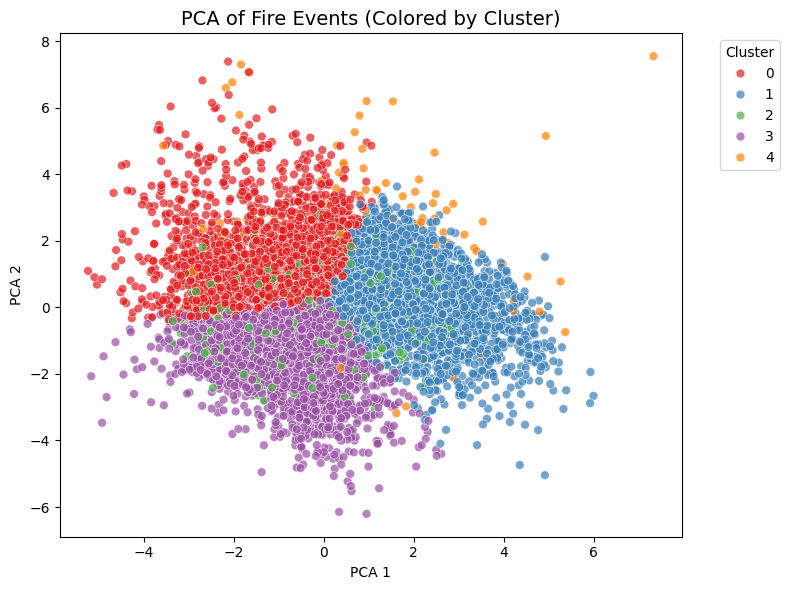

✅ Cluster summary saved as cluster_summary.xlsx


In [14]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ✅ Use only the 14 valid numeric features
features = [
    'Elevation','Slope','Aspect','LandCover','TreeCover',
    'Population','DistanceRoad','DistanceSettlement',
    'Temperature','Humidity','WindSpeed','Precip3Days','NDVI',
    'MSI', 'month_sin','month_cos'
]


# --- 1. Run KMeans clustering ---
k = 5  # number of clusters (can adjust)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
fire_df['Cluster'] = kmeans.fit_predict(X)

print("✅ Clustering done")
print(fire_df['Cluster'].value_counts())

# --- 2. Inspect cluster centers (in original scale) ---
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)
print("\nCluster centers (original scale):")
print(cluster_centers.round(2))

# --- 3. PCA for visualization ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

fire_df['PCA1'] = pca_result[:, 0]
fire_df['PCA2'] = pca_result[:, 1]

# --- 4. Plot PCA scatter with clusters ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=fire_df,
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='Set1',
    s=40, alpha=0.7
)
plt.title("PCA of Fire Events (Colored by Cluster)", fontsize=14)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 5. Save cluster summary table ---
cluster_summary = fire_df.groupby('Cluster')[features].mean().round(2)
cluster_summary.to_excel("cluster_summary.xlsx")
print("✅ Cluster summary saved as cluster_summary.xlsx")


In [15]:
import folium
import geopandas as gpd

# Convert fire_data into a GeoDataFrame
fire_gdf = gpd.GeoDataFrame(
    fire_df,
    geometry=gpd.points_from_xy(fire_df['longitude'], fire_df['latitude']),
    crs="EPSG:4326"
)

# Create a folium map centered on Norway
m = folium.Map(location=[64, 11], zoom_start=5)

# Cluster colors
colors = ['red', 'blue', 'green', 'purple', 'orange']

# Add points
for _, row in fire_gdf.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=colors[row['Cluster']],
        fill=True,
        fill_opacity=0.7,
        popup=f"Fire ID: {row['fire_id']}, Cluster: {row['Cluster']}"
    ).add_to(m)

# Save map
m.save("fire_clusters_map.html")
print("✅ Interactive map saved as fire_clusters_map.html")


✅ Interactive map saved as fire_clusters_map.html


✅ Using features: ['Elevation', 'Slope', 'Aspect', 'LandCover', 'TreeCover', 'Population', 'DistanceRoad', 'DistanceSettlement', 'Temperature', 'Humidity', 'WindSpeed', 'Precip3Days', 'NDVI', 'NDWI', 'MSI']
Fires per cluster:
 Cluster
3    2918
1    2878
0    2309
2     417
4     108
Name: count, dtype: int64

Per-cluster z-score means (higher = above dataset average):
         Elevation  Slope  Aspect  LandCover  TreeCover  Population  \
Cluster                                                               
0            -0.51  -0.61   -0.72       1.12      -0.97       -0.06   
1             0.25   0.21    0.21      -0.50       0.54       -0.25   
2             0.28  -0.21    0.95      -0.33      -0.52        3.88   
3             0.09   0.30    0.23      -0.40       0.36       -0.24   
4             0.73   0.14   -0.21       1.51      -1.20       -0.48   

         DistanceRoad  DistanceSettlement  Temperature  Humidity  WindSpeed  \
Cluster                                            

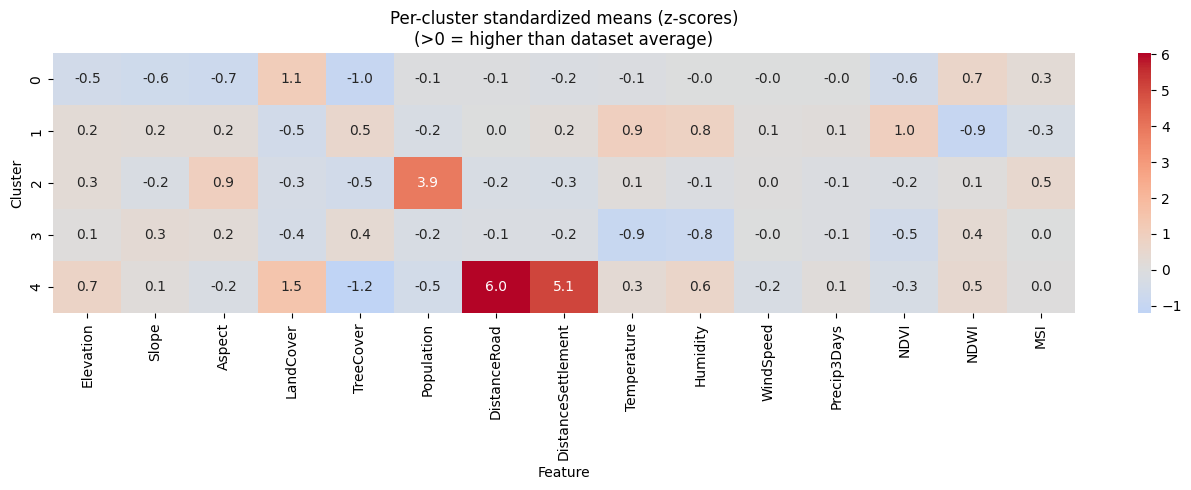


Auto-summaries per cluster:
Cluster
0    higher landcover, surface water (NDWI); lower ...
1    higher temperature, humidity, veg greenness (N...
2                            higher aspect, population
3                          lower temperature, humidity
4    higher elevation, landcover, distance to roads...
Name: AutoSummary, dtype: object

💾 Saved: cluster_auto_descriptions.xlsx


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif

# ---------------------------------------------------
# 0) Setup: use the features you care about (only keep those that exist)
# ---------------------------------------------------
all_features = [
    'Elevation','Slope','Aspect','LandCover','TreeCover',
    'Population','DistanceRoad','DistanceSettlement',
    'Temperature','Humidity','WindSpeed','Precip3Days',
    'NDVI','NDWI','MSI'
]
assert 'Cluster' in fire_df.columns, "fire_df must contain a 'Cluster' column."

features = [f for f in all_features if f in fire_df.columns]
num = fire_df[features].copy()

# ---------------------------------------------------
# 1) Clean (impute) + standardize (z-score)
# ---------------------------------------------------
imp = SimpleImputer(strategy="median")
X = imp.fit_transform(num)

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

Z = pd.DataFrame(Xz, columns=features, index=fire_df.index)
Z['Cluster'] = fire_df['Cluster'].values

print("✅ Using features:", features)
print("Fires per cluster:\n", Z['Cluster'].value_counts())

# ---------------------------------------------------
# 2) Per-cluster standardized means (z-scores)
#    (>0 means higher than dataset average; <0 lower)
# ---------------------------------------------------
z_means = Z.groupby('Cluster')[features].mean().round(2)
print("\nPer-cluster z-score means (higher = above dataset average):")
print(z_means)

# ---------------------------------------------------
# 3) For each cluster, list the strongest highs/lows
# ---------------------------------------------------
def top_high_low(row, k=5):
    highs = row.sort_values(ascending=False).head(k)
    lows  = row.sort_values(ascending=True).head(k)
    return highs, lows

for cl, row in z_means.iterrows():
    highs, lows = top_high_low(row, k=min(5, len(features)))
    print(f"\n—— Cluster {cl} —————————————————")
    print("Top HIGH (z):", ", ".join([f"{f} ({v:+.2f})" for f, v in highs.items()]))
    print("Top  LOW  (z):", ", ".join([f"{f} ({v:+.2f})" for f, v in lows.items()]))

# ---------------------------------------------------
# 4) Which features best separate clusters? (ANOVA F)
# ---------------------------------------------------
y = fire_df['Cluster'].values
F, p = f_classif(X, y)
importance = pd.DataFrame({'feature': features, 'F_score': F, 'p_value': p}) \
               .sort_values('F_score', ascending=False)
print("\nFeatures that best separate clusters (ANOVA F-score):")
print(importance)

# ---------------------------------------------------
# 5) Heatmap of per-cluster z-means
# ---------------------------------------------------
plt.figure(figsize=(max(8, 0.9*len(features)), 5))
sns.heatmap(z_means, cmap='coolwarm', center=0, annot=True, fmt=".1f")
plt.title("Per-cluster standardized means (z-scores)\n(>0 = higher than dataset average)")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 6) Auto-generate one-line English summaries per cluster
# ---------------------------------------------------
# Thresholds for calling something "high"/"low"
HI, LO = 0.6, -0.6

def feature_label(name):
    # Optional: make labels more readable on the summary line
    return {
        'NDVI':'veg greenness (NDVI)',
        'NDWI':'surface water (NDWI)',
        'MSI':'canopy dryness (MSI)',
        'WindSpeed':'wind speed',
        'Precip3Days':'rain last 3d',
        'DistanceRoad':'distance to roads',
        'DistanceSettlement':'distance to settlements'
    }.get(name, name.lower())

def summarize_row(row):
    highs = [feature_label(f) for f, v in row.items() if v >= HI]
    lows  = [feature_label(f) for f, v in row.items() if v <= LO]
    parts = []
    if highs: parts.append("higher " + ", ".join(highs))
    if lows:  parts.append("lower " + ", ".join(lows))
    return "; ".join(parts) if parts else "near-average across most features"

auto_summary = z_means.apply(summarize_row, axis=1).rename("AutoSummary")
print("\nAuto-summaries per cluster:")
print(auto_summary)

# Save machine-readable summaries for your slide notes
summary_table = z_means.copy()
summary_table['AutoSummary'] = auto_summary
summary_table.to_excel("cluster_auto_descriptions.xlsx")
print("\n💾 Saved: cluster_auto_descriptions.xlsx")


In [22]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

# --- 1. Load Norway boundaries ---
countries = gpd.read_file("ne_110m_admin_0_countries.shp")
norway = countries[countries['NAME'] == "Norway"].to_crs(epsg=32633)

# --- 2. Exclude Svalbard & Jan Mayen ---
# Keep only polygons with southern (mainland) coordinates
norway_mainland = norway.copy()
norway_mainland["area"] = norway_mainland.geometry.area

# Filter polygons south of 70°N (mainland Norway ends around 71°)
norway_mainland = norway_mainland.explode(index_parts=True)
norway_mainland = norway_mainland[norway_mainland.geometry.centroid.y < 7900000]  # ~71°N in UTM 33N
norway_mainland = norway_mainland.dissolve()  # merge back into one mainland polygon

print(f"✅ Mainland Norway extracted (no Svalbard).")

# --- 3. Generate random points inside mainland polygon ---
def generate_points_in_polygon(polygon, n_points):
    minx, miny, maxx, maxy = polygon.bounds
    points = []
    while len(points) < n_points:
        x = np.random.uniform(minx, maxx)
        y = np.random.uniform(miny, maxy)
        p = Point(x, y)
        if polygon.contains(p):
            points.append(p)
    return points

n_candidates = len(fire_df) * 2  # oversample
norway_geom = norway_mainland.geometry.iloc[0]
candidate_points = generate_points_in_polygon(norway_geom, n_candidates)
candidates = gpd.GeoDataFrame(geometry=candidate_points, crs=norway_mainland.crs)

# --- 4. Reproject fires & create 10 km exclusion buffer ---
fire_gdf = gpd.GeoDataFrame(
    fire_df,
    geometry=gpd.points_from_xy(fire_df['longitude'], fire_df['latitude']),
    crs="EPSG:4326"
).to_crs(epsg=32633)

buffer = fire_gdf.buffer(2000)

# --- 5. Filter out points that fall inside any fire buffer ---
candidates = candidates[~candidates.geometry.apply(lambda g: buffer.intersects(g).any())]
print(f"✅ Remaining non-fire candidates inside mainland Norway: {len(candidates)}")

# --- 6. Convert to WGS84 and save ---
candidates = candidates.to_crs(epsg=4326)
candidates_df = pd.DataFrame({
    "latitude": candidates.geometry.y,
    "longitude": candidates.geometry.x
})
candidates_df.to_excel("non_fire_candidates_mainland.xlsx", index=False)
print("✅ Saved: non_fire_candidates_mainland.xlsx (Svalbard excluded)")


✅ Mainland Norway extracted (no Svalbard).
✅ Remaining non-fire candidates inside mainland Norway: 15219
✅ Saved: non_fire_candidates_mainland.xlsx (Svalbard excluded)


In [ ]:
"""
countries = gpd.read_file("ne_110m_admin_0_countries.shp")
norway = countries[countries['NAME'] == "Norway"]


In [ ]:
""""
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
import geodatasets


# Project to UTM for accurate buffering & area-based sampling
norway = norway.to_crs(epsg=32633)

# --- 2. Generate random points inside Norway polygon ---
def generate_points_in_polygon(polygon, n_points):
    minx, miny, maxx, maxy = polygon.bounds
    points = []
    while len(points) < n_points:
        x = np.random.uniform(minx, maxx)
        y = np.random.uniform(miny, maxy)
        p = Point(x, y)
        if polygon.contains(p):
            points.append(p)
    return points

n_candidates = len(fire_df) * 10  # oversample
norway_geom = norway.geometry.iloc[0]
candidate_points = generate_points_in_polygon(norway_geom, n_candidates)

candidates = gpd.GeoDataFrame(geometry=candidate_points, crs=norway.crs)

# --- 3. Reproject fires & buffer ---
fire_gdf = gpd.GeoDataFrame(
    fire_df,
    geometry=gpd.points_from_xy(fire_df['longitude'], fire_df['latitude']),
    crs="EPSG:4326"
).to_crs(epsg=32633)

buffer = fire_gdf.buffer(10000)  # 10 km exclusion

# --- 4. Remove candidates inside fire buffers ---
candidates = candidates[~candidates.geometry.apply(lambda g: buffer.intersects(g).any())]

# Back to WGS84 lat/lon
candidates = candidates.to_crs(epsg=4326)

print(f"✅ Remaining non-fire candidates inside Norway: {len(candidates)}")

# --- 5. Save candidates (lat/lon only) ---
candidates_df = pd.DataFrame({
    "latitude": candidates.geometry.y,
    "longitude": candidates.geometry.x
})
candidates_df.to_excel("non_fire_candidates_norway.xlsx", index=False)
print("✅ Saved to non_fire_candidates_norway.xlsx")


In [23]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

# --- 1. Load candidate non-fire points (Excel) ---
candidates_df = pd.read_excel("non_fire_candidates_mainland.xlsx")

# --- 2. Convert to GeoDataFrame ---
candidates = gpd.GeoDataFrame(
    candidates_df,
    geometry=gpd.points_from_xy(candidates_df['longitude'], candidates_df['latitude']),
    crs="EPSG:4326"
)

print(f"✅ Loaded {len(candidates)} candidate points inside Norway")

# --- 3. Stratified sampling by fire clusters ---
non_fire_list = []
for cluster_id, group in fire_df.groupby('Cluster'):
    n = len(group)  # same number of non-fires as fires in this cluster
    
    # Randomly sample candidates for this cluster
    cand_cluster = candidates.sample(n, random_state=cluster_id*100)
    
    # Assign dates from the same cluster (seasonality preserved)
    cluster_dates = group['date'].values
    cand_cluster['date'] = np.random.choice(cluster_dates, size=n)
    
    cand_cluster['Cluster'] = cluster_id
    cand_cluster['fire_label'] = 0
    non_fire_list.append(cand_cluster)

# --- 4. Combine all clusters ---
non_fire_final = pd.concat(non_fire_list)

# --- 5. Add IDs and coordinates ---
non_fire_final['nonfire_id'] = range(1, len(non_fire_final)+1)
non_fire_final['latitude'] = non_fire_final.geometry.y
non_fire_final['longitude'] = non_fire_final.geometry.x

# --- 6. Save final non-fire events ---
non_fire_final[['nonfire_id','latitude','longitude','date','Cluster','fire_label']]\
    .to_excel("non_fire_events.xlsx", index=False)

print("✅ Stratified non-fire dataset with seasonality saved as non_fire_events.xlsx")


✅ Loaded 15219 candidate points inside Norway
✅ Stratified non-fire dataset with seasonality saved as non_fire_events.xlsx


In [24]:
import folium

# Create a folium map centered on Norway
m = folium.Map(location=[64, 11], zoom_start=5)

# Colors for fire clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']

# Plot fire points (from fire_df)
for _, row in fire_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=colors[row['Cluster']],
        fill=True,
        fill_opacity=0.7,
        popup=f"🔥 Fire | Cluster: {row['Cluster']}"
    ).add_to(m)

# Plot non-fire points in black
for _, row in non_fire_final.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color="black",
        fill=True,
        fill_opacity=0.5,
        popup=f"🌿 Non-fire | Cluster: {row['Cluster']}"
    ).add_to(m)

# Save interactive map
m.save("fires_nonfires_map.html")
print("✅ Interactive map saved as fires_nonfires_map.html")


✅ Interactive map saved as fires_nonfires_map.html
